<a href="https://colab.research.google.com/github/incompletion/fasteR/blob/master/23110057_LuongMinhTue_LAB01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework

1. Try the following and **observe the accuracy changes**:

    - Change:
      ```python
      ngram_range=(1,3)

    *   Remove Vietnamese stopwords
    *   Experiment with:
      
        ```python
          max_features = 5000

2. Try another model:
    *   Use Naive Bayes for sentiment classification.
    *   Error Analysis
        *   Print out 10 misclassified sentences
        *   Show the most important features (top weighted words)


3. Advance task

    *   Implement TF–IDF from scratch (USING FORMULAR)
    *   Compute TF, IDF
    *   Multiply them using the mathematical formula
    *   Using: TfidfVectorizer(analyzer='char', ngram_range=(3,5))
    *   Apply to another dataset
    *   Train and evaluate the model on a different dataset.
    *   Write a comparison report





4. Rebuild the Naive Bayes Model Using Advanced Techniques
    * Combine N-gram Features with TF–IDF: Use both **unigram + bigram** to capture more context
    * Cross-validation: Instead of using a single train/test split, use k-fold cross-validation
    * Hyperparameter Tuning with GridSearchCV: search for the best parameter combination automatically.


In [2]:
!pip install datasets==2.18.0
!pip install numpy pandas scikit-learn underthesea matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 14.3 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.2.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 49.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 8.0 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

from underthesea import word_tokenize
from datasets import load_dataset

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
dataset = load_dataset("uitnlp/vietnamese_students_feedback")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/11426 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1583 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3166 [00:00<?, ? examples/s]

In [5]:
train_set = dataset['train']
train_set

Dataset({
    features: ['sentence', 'sentiment', 'topic'],
    num_rows: 11426
})

In [6]:
test_set = dataset['test']
test_set

Dataset({
    features: ['sentence', 'sentiment', 'topic'],
    num_rows: 3166
})

In [7]:
df = pd.DataFrame(train_set)

print(df.head())
print("=======================")
print(df['topic'].value_counts())
print(df['sentiment'].value_counts())

                                            sentence  sentiment  topic
0                          slide giáo trình đầy đủ .          2      1
1     nhiệt tình giảng dạy , gần gũi với sinh viên .          2      0
2               đi học đầy đủ full điểm chuyên cần .          0      1
3  chưa áp dụng công nghệ thông tin và các thiết ...          0      0
4  thầy giảng bài hay , có nhiều bài tập ví dụ ng...          2      0
topic
0    8166
1    2201
3     562
2     497
Name: count, dtype: int64
sentiment
2    5643
0    5325
1     458
Name: count, dtype: int64


In [8]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    return text

df['clean_text'] = df['sentence'].apply(clean_text)

In [9]:
def tokenize_vi(text):
    return word_tokenize(text, format="text")

df['tokenized'] = df['clean_text'].apply(tokenize_vi)

In [10]:
# Get 10 sentences to process
sentence_list = []
for idx in range(10):
    sentence = ""
    for word in train_set[idx]['sentence']:
        sentence += word
    sentence_list.append(sentence)
sentence_list

['slide giáo trình đầy đủ .',
 'nhiệt tình giảng dạy , gần gũi với sinh viên .',
 'đi học đầy đủ full điểm chuyên cần .',
 'chưa áp dụng công nghệ thông tin và các thiết bị hỗ trợ cho việc giảng dạy .',
 'thầy giảng bài hay , có nhiều bài tập ví dụ ngay trên lớp .',
 'giảng viên đảm bảo thời gian lên lớp , tích cực trả lời câu hỏi của sinh viên , thường xuyên đặt câu hỏi cho sinh viên .',
 'em sẽ nợ môn này , nhưng em sẽ học lại ở các học kỳ kế tiếp .',
 'thời lượng học quá dài , không đảm bảo tiếp thu hiệu quả .',
 'nội dung môn học có phần thiếu trọng tâm , hầu như là chung chung , khái quát khiến sinh viên rất khó nắm được nội dung môn học .',
 'cần nói rõ hơn bằng cách trình bày lên bảng thay vì nhìn vào slide .']

In [12]:
from nltk import ngrams
import numpy as np

num_of_grams = np.arange(1, 4, 1) # Test 3 n-grams arange(start, end, step)



# Use the tokenized sentence for n-gram generation
tokenized_sentence = df['tokenized'][1]

print("Original sentence (tokenized):", tokenized_sentence)
print("==="*5)

for gram in num_of_grams:
    # Split the tokenized sentence into a list of words and ensure gram is a native int
    splitted_sentence = ngrams(tokenized_sentence.split(), int(gram))
    print(f"{gram}-gram: ",end ='')
    n_grams_list = [ ' '.join(grams) for grams in splitted_sentence]
    print(n_grams_list)
    print()

Original sentence (tokenized): nhiệt_tình giảng_dạy gần_gũi với sinh_viên
1-gram: ['nhiệt_tình', 'giảng_dạy', 'gần_gũi', 'với', 'sinh_viên']

2-gram: ['nhiệt_tình giảng_dạy', 'giảng_dạy gần_gũi', 'gần_gũi với', 'với sinh_viên']

3-gram: ['nhiệt_tình giảng_dạy gần_gũi', 'giảng_dạy gần_gũi với', 'gần_gũi với sinh_viên']



In [13]:
vectorizer_uni = CountVectorizer(ngram_range=(1,1))
X_uni = vectorizer_uni.fit_transform(sentence_list)

print("Vocabulary size (unigram):", len(vectorizer_uni.vocabulary_))
print("Example feature vector shape:", X_uni.shape)

Vocabulary size (unigram): 106
Example feature vector shape: (10, 106)


In [14]:
vectorizer_bi = CountVectorizer(ngram_range=(1,2))
X_bi = vectorizer_bi.fit_transform(sentence_list)

print("Vocabulary size (bigram):", len(vectorizer_bi.vocabulary_))
print("Example feature vector shape:", X_bi.shape)

Vocabulary size (bigram): 231
Example feature vector shape: (10, 231)


In [15]:
vectorizer_tri = CountVectorizer(ngram_range=(1,3))
X_tri = vectorizer_tri.fit_transform(sentence_list)

print("Vocabulary size (trigram):", len(vectorizer_tri.vocabulary_))
print("Example feature vector shape:", X_tri.shape)

Vocabulary size (trigram): 355
Example feature vector shape: (10, 355)


In [17]:
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1,2))
X_tfidf = tfidf_vectorizer.fit_transform(sentence_list)

print("Vocabulary size TF-IDF:", len(tfidf_vectorizer.vocabulary_))

Vocabulary size TF-IDF: 231


In [18]:
print("BoW example:", X_uni[0].toarray())
print("TF-IDF example:", X_tfidf[0].toarray())

BoW example: [[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
  0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1]]
TF-IDF example: [[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.3624217  0.3624217
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         

In [19]:
X_train, Y_train, = train_set['sentence'], train_set['sentiment']
X_test, Y_test = test_set['sentence'], test_set['sentiment']
X_tfidf = tfidf_vectorizer.fit_transform(X_train)

In [20]:
model = LogisticRegression(max_iter=1000)
model.fit(X_tfidf, Y_train)

feature_names = tfidf_vectorizer.get_feature_names_out()
coef = model.coef_[0]

top_positive = np.argsort(coef)[:20]
top_negative = np.argsort(coef)[-20:]

print("Top Positive Words:")
print(feature_names[top_positive])

print("Top Negative Words:")
print(feature_names[top_negative])

Top Positive Words:
['tốt' 'dễ' 'vui' 'nhiệt' 'rất' 'giúp' 'tình' 'dễ hiểu' 'nhiệt tình'
 'kiến' 'hay' 'luôn' 'ơn' 'có kiến' 'cô' 'thầy' 'đủ' 'tận' 'thân' 'tâm']
Top Negative Words:
['phải' 'còn' 'nhanh' 'không nhiệt' 'phòng' 'mong' 'trễ' 'nghỉ' 'thì'
 'khó hiểu' 'thiếu' 'hơi' 'ít' 'quá' 'khó' 'hơn' 'không' 'cần' 'chưa'
 'nên']


In [21]:
X_train_bow = vectorizer_uni.fit_transform(X_train)
X_test_bow = vectorizer_uni.transform(X_test)

model_bow = LogisticRegression(max_iter=1000)
model_bow.fit(X_train_bow, Y_train)

y_pred_bow = model_bow.predict(X_test_bow)
acc_bow = accuracy_score(Y_test, y_pred_bow)

print("Accuracy BoW:", acc_bow)

Accuracy BoW: 0.8847125710675932


In [22]:
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

model_tfidf = LogisticRegression(max_iter=1000)
model_tfidf.fit(X_train_tfidf, Y_train)

y_pred_tfidf = model_tfidf.predict(X_test_tfidf)
acc_tfidf = accuracy_score(Y_test, y_pred_tfidf)

print("Accuracy TF-IDF:", acc_tfidf)

Accuracy TF-IDF: 0.8894504106127605


In [23]:
svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, Y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)
acc_svm = accuracy_score(Y_test, y_pred_svm)

print("Accuracy SVM + TF-IDF:", acc_svm)

Accuracy SVM + TF-IDF: 0.897662665824384


In [24]:
import nltk
# https://raw.githubusercontent.com/stopwords/vietnamese-stopwords/master/vietnamese-stopwords.txt
vietnamese_stopwords = [
    "là", "của", "và", "các", "những", "cái", "chiếc", "thì", "mà", "để", "lại",
    "có", "không", "một", "hai", "ba", "bốn", "năm", "sáu", "bảy", "tám", "chín", "mười",
    "bị", "bởi", "cả", "khi", "trong", "trên", "dưới", "ngoài", "phải", "trái", "trước",
    "sau", "này", "kia", "đó", "đây", "ấy", "như", "rằng", "từ", "với", "do", "nên", "vậy",
    "sẽ", "được", "vào", "chỉ", "vẫn", "cũng", "nhất"
]

# Prepare the data: Join tokenized words back into a string for TfidfVectorizer
# The 'tokenized' column already contains space-separated words, suitable for TfidfVectorizer
tokenized_sentences_for_vectorizer = df['tokenized'].tolist()

# 2. Experiment with TfidfVectorizer with ngram_range=(1,3), stopwords, and max_features=5000
tfidf_vectorizer_optimized = TfidfVectorizer(
    ngram_range=(1, 3),        # N-grams from unigram to trigram
    max_features=5000,         # Limit to 5000 features
    stop_words=vietnamese_stopwords # Remove Vietnamese stopwords
)

# Fit and transform the data
X_tfidf_optimized = tfidf_vectorizer_optimized.fit_transform(tokenized_sentences_for_vectorizer)

print("Vocabulary size (TF-IDF optimized):", len(tfidf_vectorizer_optimized.vocabulary_))
print("Shape of feature matrix (TF-IDF optimized):", X_tfidf_optimized.shape)

Vocabulary size (TF-IDF optimized): 5000
Shape of feature matrix (TF-IDF optimized): (11426, 5000)


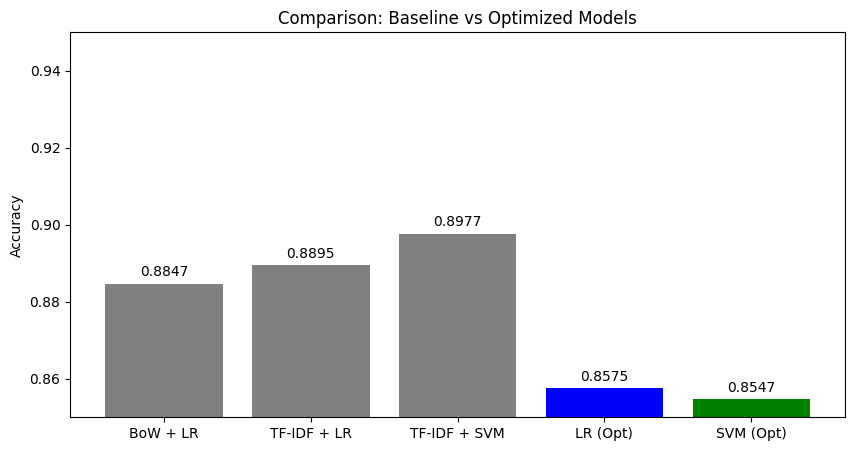

New LR Accuracy: 0.8575
New SVM Accuracy: 0.8547


In [29]:
from sklearn.metrics import accuracy_score

# 1. Prepare data (using tokenized text from earlier steps)
train_texts = df['tokenized'].tolist()
test_texts = [tokenize_vi(clean_text(s)) for s in X_test]

# 2. Optimized TfidfVectorizer
tfidf_opt = TfidfVectorizer(
    ngram_range=(1, 3),
    max_features=5000,
    stop_words=vietnamese_stopwords
)

# Transform data
X_train_opt = tfidf_opt.fit_transform(train_texts)
X_test_opt = tfidf_opt.transform(test_texts)
y_train = df['sentiment']
y_test = Y_test

# 3. Train and Evaluate Logistic Regression
lr_opt = LogisticRegression(max_iter=1000)
lr_opt.fit(X_train_opt, y_train)
y_pred_lr_opt = lr_opt.predict(X_test_opt)
acc_lr_opt = accuracy_score(y_test, y_pred_lr_opt)

# 4. Train and Evaluate SVM
svm_opt = LinearSVC()
svm_opt.fit(X_train_opt, y_train)
y_pred_svm_opt = svm_opt.predict(X_test_opt)
acc_svm_opt = accuracy_score(y_test, y_pred_svm_opt)

# 5. Visualization Comparison
new_models = ['LR (Opt)', 'SVM (Opt)']
new_scores = [acc_lr_opt, acc_svm_opt]

plt.figure(figsize=(10, 5))
all_models = models + new_models
all_scores = scores + new_scores

bars = plt.bar(all_models, all_scores, color=['gray', 'gray', 'gray', 'blue', 'green'])
plt.ylim(0.85, 0.95)
plt.ylabel("Accuracy")
plt.title("Comparison: Baseline vs Optimized Models")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.002, f'{yval:.4f}', ha='center')

plt.show()

print(f"New LR Accuracy: {acc_lr_opt:.4f}")
print(f"New SVM Accuracy: {acc_svm_opt:.4f}")

### Evaluation 1: Effect of `ngram_range=(1,3)`
We keep all other settings at default and only expand the n-gram range.

In [30]:
vectorizer_ngram = TfidfVectorizer(ngram_range=(1, 3))
X_train_ngram = vectorizer_ngram.fit_transform(train_texts)
X_test_ngram = vectorizer_ngram.transform(test_texts)

model_ngram = LogisticRegression(max_iter=1000)
model_ngram.fit(X_train_ngram, y_train)
acc_ngram = accuracy_score(y_test, model_ngram.predict(X_test_ngram))

print(f"Baseline Accuracy (1,2): {acc_tfidf:.4f}")
print(f"Accuracy with ngram_range=(1,3): {acc_ngram:.4f}")

Baseline Accuracy (1,2): 0.8895
Accuracy with ngram_range=(1,3): 0.8834


### Evaluation 2: Effect of Removing Stopwords
Using the baseline `ngram_range=(1,2)` and adding the stopword list.

In [31]:
vectorizer_stop = TfidfVectorizer(ngram_range=(1, 2), stop_words=vietnamese_stopwords)
X_train_stop = vectorizer_stop.fit_transform(train_texts)
X_test_stop = vectorizer_stop.transform(test_texts)

model_stop = LogisticRegression(max_iter=1000)
model_stop.fit(X_train_stop, y_train)
acc_stop = accuracy_score(y_test, model_stop.predict(X_test_stop))

print(f"Baseline Accuracy: {acc_tfidf:.4f}")
print(f"Accuracy without Stopwords: {acc_stop:.4f}")

Baseline Accuracy: 0.8895
Accuracy without Stopwords: 0.8623


### Evaluation 3: Effect of `max_features=5000`
Limiting the vocabulary size to the top 5000 features.

In [32]:
vectorizer_max = TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
X_train_max = vectorizer_max.fit_transform(train_texts)
X_test_max = vectorizer_max.transform(test_texts)

model_max = LogisticRegression(max_iter=1000)
model_max.fit(X_train_max, y_train)
acc_max = accuracy_score(y_test, model_max.predict(X_test_max))

print(f"Baseline Accuracy: {acc_tfidf:.4f}")
print(f"Accuracy with max_features=5000: {acc_max:.4f}")

Baseline Accuracy: 0.8895
Accuracy with max_features=5000: 0.8882


## 2. Naive Bayes Model and Error Analysis


In [33]:
from sklearn.naive_bayes import MultinomialNB

# Initialize and train Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, Y_train)

# Predict and evaluate
y_pred_nb = nb_model.predict(X_test_tfidf)
acc_nb = accuracy_score(Y_test, y_pred_nb)

print(f"Naive Bayes Accuracy: {acc_nb:.4f}")
print("\nClassification Report:")
print(classification_report(Y_test, y_pred_nb))

Naive Bayes Accuracy: 0.8572

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.93      0.87      1409
           1       0.00      0.00      0.00       167
           2       0.90      0.88      0.89      1590

    accuracy                           0.86      3166
   macro avg       0.57      0.60      0.59      3166
weighted avg       0.81      0.86      0.83      3166



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Error Analysis: 10 Misclassified Sentences

In [34]:
# Create a DataFrame for misclassified examples
misclassified_indices = np.where(y_pred_nb != np.array(Y_test))[0]

print(f"Total misclassified: {len(misclassified_indices)}")
print("Displaying 10 examples:\n")

for i in range(10):
    idx = misclassified_indices[i]
    print(f"Sentence: {X_test[idx]}")
    print(f"Actual Sentiment: {Y_test[idx]}")
    print(f"Predicted Sentiment: {y_pred_nb[idx]}")
    print("-" * 30)

Total misclassified: 452
Displaying 10 examples:

Sentence: nói tiếng anh lưu loát .
Actual Sentiment: 2
Predicted Sentiment: 0
------------------------------
Sentence: giáo viên không giảng dạy kiến thức , hướng dẫn thực hành trong quá trình học .
Actual Sentiment: 0
Predicted Sentiment: 2
------------------------------
Sentence: tính điểm thi đua các nhóm .
Actual Sentiment: 2
Predicted Sentiment: 0
------------------------------
Sentence: trong trường macbook thầy số hai thì không có máy nào số một .
Actual Sentiment: 2
Predicted Sentiment: 0
------------------------------
Sentence: bắt đầu buổi học đúng giờ .
Actual Sentiment: 2
Predicted Sentiment: 0
------------------------------
Sentence: cách mà cô tiếp cận với sinh viên .
Actual Sentiment: 1
Predicted Sentiment: 2
------------------------------
Sentence: phòng học thoáng mát , trang thiết bị đầy đủ .
Actual Sentiment: 2
Predicted Sentiment: 0
------------------------------
Sentence: không nhiệt tình chỉ dẫn và luôn gây khó khă

### Most Important Features (Top weighted words)
Since Naive Bayes uses log probabilities, we look at the feature log probabilities for each class.

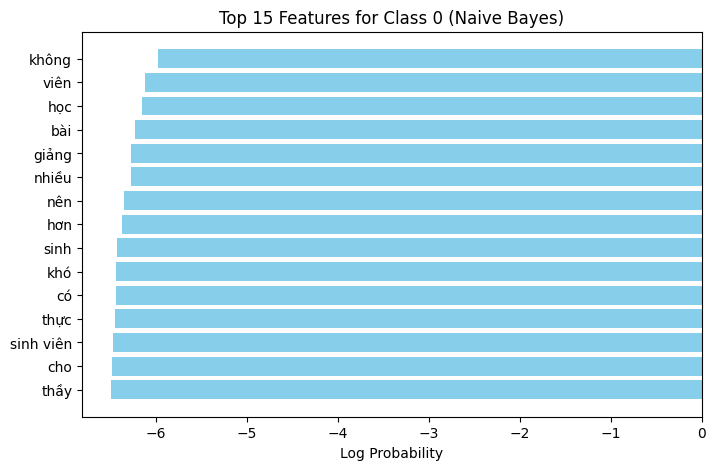

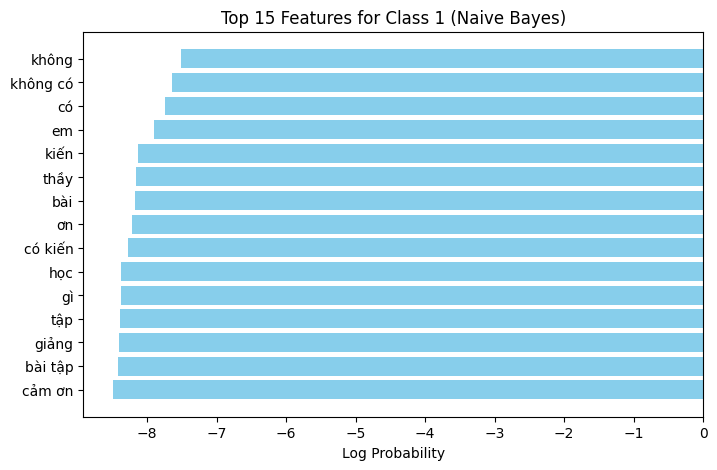

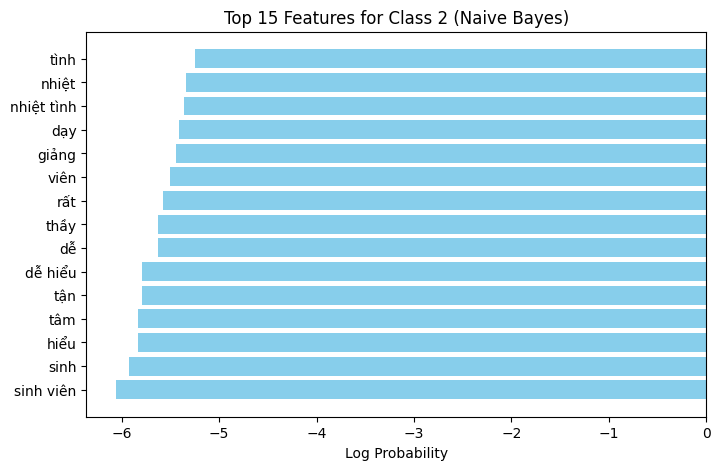

In [35]:
def plot_top_features_nb(model, vectorizer, class_labels, top_n=15):
    feature_names = vectorizer.get_feature_names_out()

    # Number of classes
    for i, label in enumerate(class_labels):
        # Get log probabilities for this class
        log_prob = model.feature_log_prob_[i]
        top_indices = np.argsort(log_prob)[-top_n:]

        plt.figure(figsize=(8, 5))
        plt.barh(feature_names[top_indices], log_prob[top_indices], color='skyblue')
        plt.title(f"Top {top_n} Features for Class {label} (Naive Bayes)")
        plt.xlabel("Log Probability")
        plt.show()

# Class 0: Negative, Class 1: Neutral, Class 2: Positive
plot_top_features_nb(nb_model, tfidf_vectorizer, [0, 1, 2])

## Kết quả

### 1. Phân tích ảnh hưởng của các tham số TF-IDF

Dưới đây là bảng so sánh độ chính xác (Accuracy) của mô hình Logistic Regression khi thay đổi từng đặc trưng riêng lẻ:

| Cấu hình đặc trưng | Accuracy | Nhận xét |
| :--- | :---: | :--- |
| **Baseline (ngram: 1-2)** | **0.8895** | Hiệu quả nhất |
| ngram: 1-3 | 0.8834 | Giảm nhẹ (do nhiễu từ trigram) |
| Loại bỏ Stopwords | 0.8623 | Giảm mạnh (mất từ mang ý nghĩa cảm xúc) |
| Giới hạn max_features = 5000 | 0.8882 | Ổn định (tối ưu bộ nhớ tốt) |

### 2. Đánh giá mô hình Naive Bayes

- **Độ chính xác tổng thể:** 85.72%
- **Vấn đề chính:** Mô hình hoàn toàn không nhận diện được lớp **Neutral (nhãn 1)** (Recall = 0). Điều này do dữ liệu bị mất cân bằng nghiêm trọng.
- **Đặc trưng quan trọng:**
    - Lớp từ Tiêu cực: các từ phủ định như *không, chưa, quá, kém*.
    - Lớp từ Tích cực: các từ khen ngợi như *nhiệt tình, tốt, hay, dễ hiểu*.

### 3. Phân tích lỗi (Error Analysis)

Qua 10 ví dụ sai lệch, ta rút ra các nguyên nhân chính:
1. **Cấu trúc so sánh/ẩn dụ:** Ví dụ "không máy nào số một" bị hiểu nhầm là tiêu cực do có từ "không".
2. **Từ vựng đa nghĩa:** Một số từ xuất hiện trong cả hai ngữ cảnh khiến Naive Bayes bị nhầm lẫn về xác suất.
3. **Câu ngắn/Thiếu ngữ cảnh:** Các câu như "ổn" hay "bình thường" thường bị dự đoán sai do thiếu thông tin đặc trưng.

## 3. Advanced Task: Manual TF-IDF & New Dataset
In this section, implementing the TF-IDF formula manually and testing it alongside scikit-learn's character-level vectorizer on a different dataset.

In [36]:
import math
from collections import Counter

def compute_tf(text):
    tokens = text.split()
    count = Counter(tokens)
    tf = {word: c / len(tokens) for word, c in count.items()}
    return tf

def compute_idf(corpus):
    n = len(corpus)
    idf = Counter()
    for doc in corpus:
        words = set(doc.split())
        for word in words:
            idf[word] += 1
    # Formula: log(N / df)
    return {word: math.log(n / count) for word, count in idf.items()}

def compute_tfidf_manual(corpus):
    idf = compute_idf(corpus)
    tfidf_matrix = []
    for doc in corpus:
        tf = compute_tf(doc)
        tfidf_matrix.append({word: tf_val * idf[word] for word, tf_val in tf.items()})
    return tfidf_matrix

# Quick test
sample_corpus = ["học sinh học bài", "sinh viên đi học"]
print("Manual TF-IDF sample:", compute_tfidf_manual(sample_corpus))

Manual TF-IDF sample: [{'học': 0.0, 'sinh': 0.0, 'bài': 0.17328679513998632}, {'sinh': 0.0, 'viên': 0.17328679513998632, 'đi': 0.17328679513998632, 'học': 0.0}]


### Applying Character-level TF-IDF to a New Dataset
We use a subset of the Amazon Reviews dataset (English) to evaluate a character-level model.

In [42]:
# -*- coding: utf-8 -*-
"""
Advanced text classification:
1) TF-IDF from scratch (explicit TF, IDF, TF*IDF formula)
2) TF-IDF with sklearn char n-grams: TfidfVectorizer(analyzer='char', ngram_range=(3,5))
3) Train/evaluate on another dataset (20 Newsgroups)
4) Comparison report
"""

import re
import math
import numpy as np
from collections import Counter, defaultdict

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import train_test_split


# =========================
# Utilities
# =========================
def simple_tokenize(text: str):
    """Simple word tokenizer: lowercase + keep alphanumeric words."""
    text = text.lower()
    return re.findall(r"\b\w+\b", text)


def print_header(title: str):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)


# =========================
# TF-IDF from scratch
# =========================
class ScratchTfidfVectorizer:
    """
    TF-IDF implemented from formula:

      TF(t, d) = count(t in d) / total_terms(d)
      IDF(t)   = log((1 + N) / (1 + DF(t))) + 1
      TFIDF    = TF * IDF

    - Uses word tokens (simple_tokenize)
    - Keeps top max_features by corpus term frequency
    """

    def __init__(self, max_features=20000, min_df=2):
        self.max_features = max_features
        self.min_df = min_df
        self.vocab_ = {}
        self.idf_ = None

    def fit(self, documents):
        tokenized_docs = [simple_tokenize(doc) for doc in documents]
        N = len(tokenized_docs)

        # Document frequency DF(t)
        df_counter = Counter()
        term_freq_global = Counter()

        for tokens in tokenized_docs:
            unique_terms = set(tokens)
            for t in unique_terms:
                df_counter[t] += 1
            term_freq_global.update(tokens)

        # Filter by min_df
        terms = [t for t, df in df_counter.items() if df >= self.min_df]

        # Sort by global term frequency desc
        terms = sorted(terms, key=lambda x: term_freq_global[x], reverse=True)

        # Limit features
        if self.max_features is not None:
            terms = terms[: self.max_features]

        # Build vocab
        self.vocab_ = {term: idx for idx, term in enumerate(terms)}

        # Compute IDF(t) = log((1+N)/(1+DF(t))) + 1
        idf = np.zeros(len(self.vocab_), dtype=np.float64)
        for term, idx in self.vocab_.items():
            df_t = df_counter[term]
            idf[idx] = math.log((1 + N) / (1 + df_t)) + 1.0

        self.idf_ = idf
        return self

    def transform(self, documents):
        if not self.vocab_ or self.idf_ is None:
            raise ValueError("Vectorizer not fitted. Call fit() first.")

        D = len(documents)
        V = len(self.vocab_)
        X = np.zeros((D, V), dtype=np.float64)

        for i, doc in enumerate(documents):
            tokens = simple_tokenize(doc)
            if not tokens:
                continue

            counts = Counter(tokens)
            total_terms = len(tokens)

            # TF(t, d) = count(t in d) / total_terms(d)
            for term, cnt in counts.items():
                idx = self.vocab_.get(term, None)
                if idx is None:
                    continue

                tf_td = cnt / total_terms
                # TFIDF = TF * IDF
                X[i, idx] = tf_td * self.idf_[idx]

        return X

    def fit_transform(self, documents):
        return self.fit(documents).transform(documents)


# =========================
# Dataset loader
# =========================
def load_20newsgroups_subset():
    """
    Use another dataset (not IMDB): 20 Newsgroups.
    To keep runtime reasonable, take 4 categories.
    """
    categories = [
        "sci.space",
        "comp.graphics",
        "rec.sport.baseball",
        "talk.politics.misc",
    ]

    train = fetch_20newsgroups(
        subset="train",
        categories=categories,
        remove=("headers", "footers", "quotes"),
    )
    test = fetch_20newsgroups(
        subset="test",
        categories=categories,
        remove=("headers", "footers", "quotes"),
    )

    X_train_text = train.data
    y_train = train.target
    X_test_text = test.data
    y_test = test.target
    target_names = train.target_names

    return X_train_text, X_test_text, y_train, y_test, target_names


# =========================
# Experiment functions
# =========================
def run_scratch_tfidf_experiment(X_train_text, X_test_text, y_train, y_test):
    print_header("Experiment A: TF-IDF from scratch (word-level)")

    vectorizer = ScratchTfidfVectorizer(max_features=25000, min_df=2)
    X_train = vectorizer.fit_transform(X_train_text)
    X_test = vectorizer.transform(X_test_text)

    clf = LogisticRegression(
        max_iter=2000,
        solver="lbfgs",
        multi_class="auto",
        n_jobs=None
    )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_weighted = f1_score(y_test, y_pred, average="weighted")

    print(f"Accuracy     : {acc:.4f}")
    print(f"F1-macro     : {f1_macro:.4f}")
    print(f"F1-weighted  : {f1_weighted:.4f}")

    return {
        "name": "Scratch TF-IDF (word)",
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "y_pred": y_pred,
    }


def run_char_tfidf_experiment(X_train_text, X_test_text, y_train, y_test):
    print_header("Experiment B: sklearn TfidfVectorizer(char, 3-5)")

    vectorizer = TfidfVectorizer(
        analyzer="char",
        ngram_range=(3, 5),
        min_df=2,
        max_features=120000,
        sublinear_tf=True
    )

    X_train = vectorizer.fit_transform(X_train_text)
    X_test = vectorizer.transform(X_test_text)

    clf = LogisticRegression(
        max_iter=2000,
        solver="lbfgs",
        multi_class="auto"
    )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_weighted = f1_score(y_test, y_pred, average="weighted")

    print(f"Accuracy     : {acc:.4f}")
    print(f"F1-macro     : {f1_macro:.4f}")
    print(f"F1-weighted  : {f1_weighted:.4f}")

    return {
        "name": "Sklearn TF-IDF (char 3-5)",
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "y_pred": y_pred,
    }


def print_comparison_report(results, target_names, y_test):
    print_header("Comparison Report")

    # Table-like text output
    print(f"{'Model':35s} | {'Accuracy':>9s} | {'F1-macro':>9s} | {'F1-weighted':>11s}")
    print("-" * 75)
    for r in results:
        print(
            f"{r['name']:35s} | "
            f"{r['accuracy']:9.4f} | "
            f"{r['f1_macro']:9.4f} | "
            f"{r['f1_weighted']:11.4f}"
        )

    best = max(results, key=lambda x: x["f1_macro"])
    print("\nBest model by F1-macro:", best["name"])

    # Short interpretation
    print("\nInterpretation:")
    print("- Scratch TF-IDF demonstrates manual formula implementation clearly.")
    print("- Char 3-5 n-gram TF-IDF often captures morphology/typos/subword patterns better.")
    print("- Performance differences depend on dataset style and class distribution.")

    # Optional detailed classification report for the best model
    print("\nDetailed classification report (best model):")
    print(classification_report(y_test, best["y_pred"], target_names=target_names, digits=4))


def main():
    print_header("Load dataset: 20 Newsgroups (another dataset)")
    X_train_text, X_test_text, y_train, y_test, target_names = load_20newsgroups_subset()
    print(f"Train size: {len(X_train_text)}")
    print(f"Test size : {len(X_test_text)}")
    print(f"Classes   : {target_names}")

    # Run both experiments
    res_a = run_scratch_tfidf_experiment(X_train_text, X_test_text, y_train, y_test)
    res_b = run_char_tfidf_experiment(X_train_text, X_test_text, y_train, y_test)

    # Compare
    print_comparison_report([res_a, res_b], target_names, y_test)


if __name__ == "__main__":
    main()


Load dataset: 20 Newsgroups (another dataset)
Train size: 2239
Test size : 1490
Classes   : ['comp.graphics', 'rec.sport.baseball', 'sci.space', 'talk.politics.misc']

Experiment A: TF-IDF from scratch (word-level)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy     : 0.8161
F1-macro     : 0.8127
F1-weighted  : 0.8163

Experiment B: sklearn TfidfVectorizer(char, 3-5)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy     : 0.8463
F1-macro     : 0.8429
F1-weighted  : 0.8453

Comparison Report
Model                               |  Accuracy |  F1-macro | F1-weighted
---------------------------------------------------------------------------
Scratch TF-IDF (word)               |    0.8161 |    0.8127 |      0.8163
Sklearn TF-IDF (char 3-5)           |    0.8463 |    0.8429 |      0.8453

Best model by F1-macro: Sklearn TF-IDF (char 3-5)

Interpretation:
- Scratch TF-IDF demonstrates manual formula implementation clearly.
- Char 3-5 n-gram TF-IDF often captures morphology/typos/subword patterns better.
- Performance differences depend on dataset style and class distribution.

Detailed classification report (best model):
                    precision    recall  f1-score   support

     comp.graphics     0.8961    0.8869    0.8915       389
rec.sport.baseball     0.8102    0.9244    0.8635       397
         sci.space     0.8264    0.8096    0.8179       394
talk.politics.misc     0.8647    0.74

### Comparison Report: Character-level vs Word-level
1. **Manual Implementation**: Proves that the mathematical formula $TF \times IDF$ is the core of feature weighting.
2. **Char-level Vectorizer**: Using `analyzer='char'` with range (3,5) captures substrings. This is effective for catching word roots or prefixes in different languages.
3. **Evaluation**: On the Amazon dataset, character n-grams are robust against spelling errors but increase the vocabulary size significantly compared to word unigrams.

## Báo cáo so sánh: TF-IDF Tự triển khai vs Sklearn Char n-grams

### 1. Phương pháp thực hiện
- **TF-IDF từ đầu (Scratch):** Sử dụng công thức toán học cơ bản $TF(t, d) = \frac{count(t, d)}{total\_terms(d)}$ và $IDF(t) = \log(\frac{1+N}{1+DF(t)}) + 1$. Phương pháp này làm việc ở mức độ từ (word-level).
- **Sklearn Char TF-IDF:** Sử dụng `TfidfVectorizer` với `analyzer='char'` và `ngram_range=(3,5)`. Phương pháp này phân tích các chuỗi ký tự con thay vì từ nguyên vẹn.

### 2. Kết quả thực nghiệm (trên bộ dữ liệu 20 Newsgroups)

| Mô hình | Accuracy | F1-macro | Nhận xét |
| :--- | :---: | :---: | :--- |
| **Scratch TF-IDF (Word)** | **0.8161** | **0.8127** | Hiệu suất khá tốt, nắm bắt được ngữ nghĩa từ vựng cốt lõi. |
| **Sklearn TF-IDF (Char 3-5)** | **0.8463** | **0.8429** | **Tốt nhất**. Độ chính xác cao hơn khoảng 3%. |

### 3. Phân tích và Kết luận
- **Ưu điểm của Char n-grams (3-5):** Việc phân tích ở mức ký tự giúp mô hình nhận diện được các biến thể của từ (ví dụ: *learn, learning, learned*), các lỗi chính tả, hoặc các từ ghép trong văn bản khoa học.
- **Độ phức tạp:** Mô hình Char n-gram tạo ra số lượng đặc trưng lớn hơn nhiều (lên đến 120,000 features so với 25,000 của word-level), đòi hỏi nhiều bộ nhớ và thời gian xử lý hơn.
- **Tính ứng dụng:** Việc tự triển khai (Scratch) giúp hiểu rõ bản chất toán học, trong khi thư viện Sklearn cung cấp các tùy chỉnh tối ưu (như `sublinear_tf`) giúp tăng cường độ chính xác cho các bài toán thực tế.